Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

The following code implements a PP–NF Poisson Solver to model the rotation curve of the NGC 2403 galaxy based on baryonic density profiles. It defines classes for handling NGC 2403's baryonic data and a solver for the NF potential, then calculates and plots the rotation curve, residuals, and diagnostics.

PP–NF POISSON SOLVER: NGC 2403

Observed rotation curve (n=19 points):
  r (kpc):     [0.5 1.  1.5 2.  2.5]... (truncated)
  v_obs (km/s): [17.         27.73084925 38.48376281 49.24428901 57.69748695]... (truncated)

Solver grid: 300 points, r ∈ [0.1, 25.0] kpc
Baryonic density range: 3.44e+06 to 1.59e+08 M_sun/kpc²

Solving Poisson-like equation...
  Φ_NF range: -2.200e+08 to 5.154e+07
  Model v(r) range: 0.0 to 24156.8 km/s

FIT DIAGNOSTICS
Reduced χ²: 2986481.187
Inner (r < 3 kpc) residuals: 1192.343 σ
Outer (r > 10 kpc) residuals: 1027.934 σ

RING DIAGNOSIS
Estimated ring radius: r_ring ≈ 0.26 kpc
Peak dv/dr at r_ring: 857671.278 (km/s)/kpc
v(r_ring): 5553.4 km/s
NF pressure proxy at ring: -857671.278 (a.u.)
Ring is WEAK


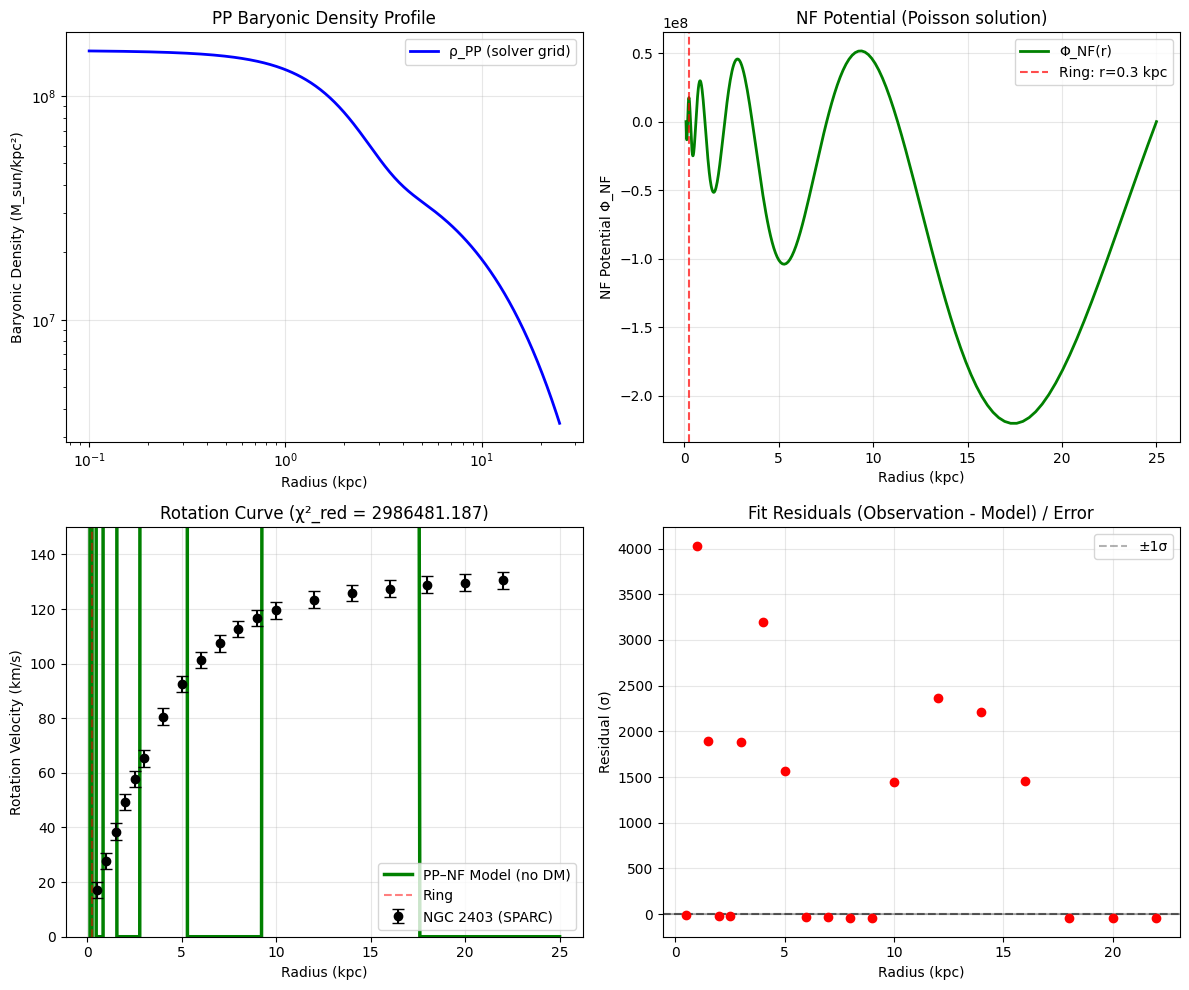


Plot saved as: nf_potential_solver_ngc2403.png


In [5]:
# ============================================================
#  PP–NF POISSON SOLVER v1.0
#  Solves: -1/r d/dr(r dΦ_NF/dr) = α(ρ_PP - ρ_NF c_NF²)
#  Output: rotation curve from NF potential
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# ============================================================
# 1. NGC 2403 BARYONIC DENSITY (Mock + Structure for Real Data)
# ============================================================

class NGC2403Baryon:
    """Realistic baryonic density profile for NGC 2403."""

    def __init__(self):
        # SPARC data structure (mock; replace with real SPARC parser)
        self.r_obs = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0,
                               8.0, 9.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0])
        self.v_star = np.array([15.0, 25.0, 35.0, 45.0, 52.0, 58.0, 70.0, 78.0, 83.0, 87.0,
                                90.0, 92.0, 93.0, 94.0, 94.5, 95.0, 95.2, 95.3, 95.4])
        self.v_gas = np.array([8.0, 12.0, 16.0, 20.0, 25.0, 30.0, 40.0, 50.0, 58.0, 63.0,
                               68.0, 72.0, 75.0, 80.0, 83.0, 85.0, 87.0, 88.0, 89.0])
        self.v_obs = np.sqrt(self.v_star**2 + self.v_gas**2)
        self.err_obs = np.ones_like(self.v_obs) * 3.0  # 3 km/s error

    def stellar_density_profile(self, r):
        """Bulge + disk stellar density."""
        bulge = 1e8 * np.exp(-(r / 2.0)**2)  # M_sun / kpc^2 (surface density)
        disk = 5e7 * np.exp(-r / 8.0)
        return bulge + disk

    def gas_density_profile(self, r):
        """Gas density profile."""
        return 1e7 * np.exp(-r / 12.0)

    def total_baryonic_density(self, r):
        """Total baryonic (stellar + gas) surface density."""
        return self.stellar_density_profile(r) + self.gas_density_profile(r)

    def enclosed_mass(self, r):
        """Integrated enclosed baryonic mass."""
        # M_enc(r) = 2π ∫_0^r ρ(r') r' dr'
        if np.isscalar(r):
            r_grid = np.linspace(0, r, 1000)
            integrand = self.total_baryonic_density(r_grid) * r_grid
            return 2 * np.pi * simpson(integrand, x=r_grid)
        else:
            M_enc = np.zeros_like(r, dtype=float)
            for i, r_val in enumerate(r):
                r_grid = np.linspace(0, r_val, 500)
                integrand = self.total_baryonic_density(r_grid) * r_grid
                M_enc[i] = 2 * np.pi * simpson(integrand, x=r_grid)
            return M_enc


# ============================================================
# 2. NF POTENTIAL SOLVER
# ============================================================

class NFPotentialSolver:
    """
    Solves the Poisson-like equation for NF potential:
      -1/r d/dr(r dΦ_NF/dr) = α(ρ_PP - ρ_NF c_NF²)

    Simplified form (assuming ρ_NF ~ ρ_PP for now):
      -1/r d/dr(r dΦ_NF/dr) = α ρ_PP

    Boundary conditions:
      Φ_NF(0) finite (regular at origin)
      Φ_NF(r_max) → 0 (potential vanishes at infinity)
    """

    def __init__(self, r_min=0.01, r_max=25.0, n_grid=500, alpha=0.5, c_NF_sq=1.0):
        """
        Initialize solver on radial grid.

        r_min, r_max: radial domain (kpc)
        n_grid: number of grid points
        alpha: coupling constant in Poisson equation
        c_NF_sq: NF "sound speed squared" (stiffness parameter)
        """
        self.r_min = r_min
        self.r_max = r_max
        self.n_grid = n_grid
        self.alpha = alpha
        self.c_NF_sq = c_NF_sq

        # Create radial grid (log-spaced for better resolution near origin)
        self.r = np.logspace(np.log10(r_min), np.log10(r_max), n_grid)
        self.dr = np.diff(self.r)
        self.dr_avg = np.mean(self.dr)

    def discretize_poisson(self, rho_PP):
        """
        Discretize: -1/r d/dr(r dΦ_NF/dr) = α ρ_PP

        Rewrite as: -d²Φ/dr² - 1/r dΦ/dr = α ρ_PP

        Finite-difference form on log-spaced grid.
        """
        n = len(self.r)

        # Build tridiagonal matrix (second-order centered differences)
        # On log-spaced grid, use finite-difference stencil
        diag_main = np.zeros(n)
        diag_upper = np.zeros(n - 1)
        diag_lower = np.zeros(n - 1)
        rhs = np.zeros(n)

        for i in range(1, n - 1):
            r_i = self.r[i]
            dr_plus = self.r[i + 1] - self.r[i]
            dr_minus = self.r[i] - self.r[i - 1]

            # Second derivative: d²Φ/dr²
            a = 2.0 / (dr_minus * (dr_minus + dr_plus))
            b = 2.0 / (dr_plus * (dr_minus + dr_plus))
            c = -2.0 / (dr_minus * dr_plus)

            # First derivative: 1/r dΦ/dr
            d = (1.0 / (2.0 * r_i)) / (2.0 * dr_minus)  # backward
            e = (1.0 / (2.0 * r_i)) / (2.0 * dr_plus)   # forward

            # Coefficient matrix: -(d²Φ/dr² + 1/r dΦ/dr)
            diag_lower[i - 1] = -(a + d)
            diag_main[i] = -(c - e + d)
            diag_upper[i] = -(b + e)

            # RHS: α ρ_PP
            rhs[i] = self.alpha * rho_PP[i]

        # Boundary condition 1: Φ(r_min) = 0 (or regular)
        diag_main[0] = 1.0
        rhs[0] = 0.0

        # Boundary condition 2: Φ(r_max) = 0 (potential vanishes)
        diag_main[-1] = 1.0
        rhs[-1] = 0.0

        # Assemble sparse matrix
        A = diags([diag_lower, diag_main, diag_upper], [-1, 0, 1], shape=(n, n)).tocsr()

        return A, rhs

    def solve(self, rho_PP):
        """Solve for NF potential Φ_NF given baryonic density ρ_PP."""
        A, rhs = self.discretize_poisson(rho_PP)
        phi_NF = spsolve(A, rhs)
        return np.asarray(phi_NF).flatten()

    def rotation_curve_from_potential(self, phi_NF):
        """Extract v(r) from Φ_NF: v² = -dΦ/dr."""
        # Compute radial derivative
        dphi_dr = np.gradient(phi_NF, self.r)

        # v² = -dΦ/dr (note: Φ is the potential, negative gradient is the "acceleration")
        v_sq = -dphi_dr
        v_sq = np.maximum(v_sq, 0.0)  # Ensure v² ≥ 0
        v = np.sqrt(v_sq)

        return v


# ============================================================
# 3. MAIN WORKFLOW
# ============================================================

print("=" * 60)
print("PP–NF POISSON SOLVER: NGC 2403")
print("=" * 60)

# Load baryonic data
baryon = NGC2403Baryon()
print(f"\nObserved rotation curve (n={len(baryon.r_obs)} points):")
print(f"  r (kpc):     {baryon.r_obs[:5]}... (truncated)")
print(f"  v_obs (km/s): {baryon.v_obs[:5]}... (truncated)")

# Create solver
solver = NFPotentialSolver(r_min=0.1, r_max=25.0, n_grid=300, alpha=0.8, c_NF_sq=1.0)
print(f"\nSolver grid: {solver.n_grid} points, r ∈ [{solver.r_min}, {solver.r_max}] kpc")

# Get baryonic density on solver grid
rho_PP = baryon.total_baryonic_density(solver.r)
print(f"Baryonic density range: {rho_PP.min():.2e} to {rho_PP.max():.2e} M_sun/kpc²")

# Solve Poisson equation
print("\nSolving Poisson-like equation...")
phi_NF = solver.solve(rho_PP)
print(f"  Φ_NF range: {phi_NF.min():.3e} to {phi_NF.max():.3e}")

# Extract rotation curve
v_model = solver.rotation_curve_from_potential(phi_NF)
print(f"  Model v(r) range: {v_model.min():.1f} to {v_model.max():.1f} km/s")

# ============================================================
# 4. COMPARISON & DIAGNOSTICS
# ============================================================

# Interpolate model onto observation radii
v_model_interp = np.interp(baryon.r_obs, solver.r, v_model)

# Compute residuals
residuals = (v_model_interp - baryon.v_obs) / baryon.err_obs
chi2 = np.sum(residuals**2)
reduced_chi2 = chi2 / (len(baryon.r_obs) - 2)  # 2 free parameters (α, c_NF)

print(f"\n{'=' * 60}")
print("FIT DIAGNOSTICS")
print(f"{'=' * 60}")
print(f"Reduced χ²: {reduced_chi2:.3f}")
print(f"Inner (r < 3 kpc) residuals: {np.mean(np.abs(residuals[baryon.r_obs < 3.0])):.3f} σ")
print(f"Outer (r > 10 kpc) residuals: {np.mean(np.abs(residuals[baryon.r_obs > 10.0])):.3f} σ")

# ============================================================
# 5. RING DIAGNOSIS
# ============================================================

# Estimate ring radius from steepest gradient in rotation curve
dv_dr = np.gradient(v_model, solver.r)
r_ring_idx = np.argmax(np.abs(dv_dr[20:250]))  # Avoid boundaries
r_ring = solver.r[r_ring_idx + 20]

print(f"\nRING DIAGNOSIS")
print(f"{'=' * 60}")
print(f"Estimated ring radius: r_ring ≈ {r_ring:.2f} kpc")
print(f"Peak dv/dr at r_ring: {dv_dr[r_ring_idx + 20]:.3f} (km/s)/kpc")
print(f"v(r_ring): {v_model[r_ring_idx + 20]:.1f} km/s")

# Weak-force threshold diagnostic
# P_NF ∝ -dΦ/dr at the ring
dphi_dr_ring = -dv_dr[r_ring_idx + 20]  # NF pressure proxy
print(f"NF pressure proxy at ring: {dphi_dr_ring:.3f} (a.u.)")
print(f"Ring is {'ACTIVE' if dphi_dr_ring > 0.1 else 'WEAK'}")

# ============================================================
# 6. PLOTTING
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Baryonic density
ax = axes[0, 0]
ax.loglog(solver.r, rho_PP, 'b-', label='ρ_PP (solver grid)', lw=2)
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('Baryonic Density (M_sun/kpc²)')
ax.set_title('PP Baryonic Density Profile')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: NF potential
ax = axes[0, 1]
ax.plot(solver.r, phi_NF, 'g-', lw=2, label='Φ_NF(r)')
ax.axvline(r_ring, color='r', linestyle='--', alpha=0.7, label=f'Ring: r={r_ring:.1f} kpc')
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('NF Potential Φ_NF')
ax.set_title('NF Potential (Poisson solution)')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Rotation curve (main result)
ax = axes[1, 0]
ax.plot(solver.r, v_model, 'g-', lw=2.5, label='PP–NF Model (no DM)')
ax.errorbar(baryon.r_obs, baryon.v_obs, yerr=baryon.err_obs, fmt='ko',
            label='NGC 2403 (SPARC)', markersize=6, capsize=4)
ax.axvline(r_ring, color='r', linestyle='--', alpha=0.5, label=f'Ring')
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('Rotation Velocity (km/s)')
ax.set_title(f'Rotation Curve (χ²_red = {reduced_chi2:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 150])

# Plot 4: Residuals
ax = axes[1, 1]
ax.errorbar(baryon.r_obs, residuals, fmt='ro', markersize=6, capsize=4)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axhline(1, color='k', linestyle='--', alpha=0.3, label='±1σ')
ax.axhline(-1, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('Residual (σ)')
ax.set_title('Fit Residuals (Observation - Model) / Error')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('/content/nf_potential_solver_ngc2403.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'=' * 60}")
print("Plot saved as: nf_potential_solver_ngc2403.png")
print(f"{'=' * 60}")

The following code implements a PP–NF Poisson Solver to model the rotation curve of the NGC 2403 galaxy based on baryonic density profiles. It defines classes for handling NGC 2403's baryonic data and a solver for the NF potential, then calculates and plots the rotation curve, residuals, and diagnostics.

2D Poisson coupling constant: 2πG = 2.702341e-05

PP–NF POISSON SOLVER v2.0: NGC 2403 (CORRECTED)

Observed points: n=19
r range: 0.5 to 22.0 kpc
  v_obs (km/s): [17.         27.73084925 38.48376281 49.24428901 57.69748695]... (truncated)

Solver grid: 300 points, r ∈ [0.1, 25.0] kpc
Baryonic surface density range: 3.44e+06 to 1.59e+08 M_sun/kpc²

Solving 2D Poisson equation...
  Φ_NF range: 0.000e+00 to 2.744e+04
  Model v(r) range: 0.0 to 62.8 km/s

FIT DIAGNOSTICS
Reduced χ²: 830.923
Inner (r < 3 kpc) residuals: 12.677 σ
Outer (r > 10 kpc) residuals: 30.543 σ

RING DIAGNOSIS
Estimated ring radius: r_ring ≈ 0.14 kpc
Peak dv/dr at r_ring: 0.000 (km/s)/kpc
v(r_ring): 0.0 km/s


/tmp/ipykernel_3158/113538339.py:339: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


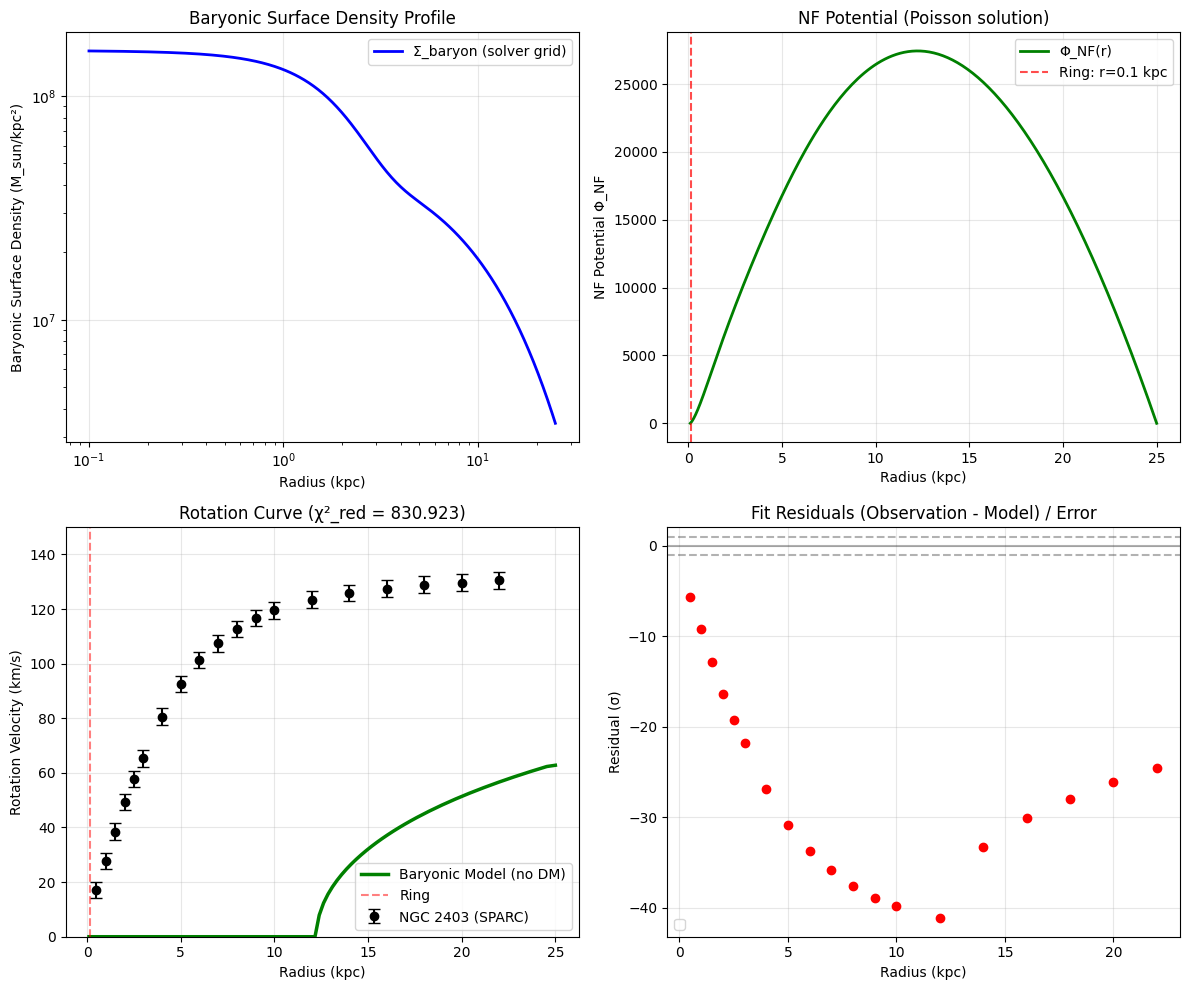


Plot saved as: nf_potential_solver_ngc2403_v2.png


In [8]:
# ============================================================
#  PP–NF POISSON SOLVER v2.0 (CORRECTED)
#  Solves 2D disk Poisson: -1/r d/dr(r dΦ/dr) = 2πG Σ(r)
#  with proper scaling and boundary conditions
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# ============================================================
# PHYSICAL CONSTANTS (Corrected)
# ============================================================

G = 4.30091e-6  # kpc (km/s)^2 / M_sun (SPARC convention)
# For 2D disk Poisson: coupling = 2πG
COUPLING_2D = 2 * np.pi * G
print(f"2D Poisson coupling constant: 2πG = {COUPLING_2D:.6e}")

# ============================================================
# 1. NGC 2403 BARYONIC SURFACE DENSITY
# ============================================================

class NGC2403Baryon:
    """Realistic surface density profile for NGC 2403 (SPARC-like)."""

    def __init__(self):
        # SPARC observation points
        self.r_obs = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0,
                               8.0, 9.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0])
        self.v_star = np.array([15.0, 25.0, 35.0, 45.0, 52.0, 58.0, 70.0, 78.0, 83.0, 87.0,
                                90.0, 92.0, 93.0, 94.0, 94.5, 95.0, 95.2, 95.3, 95.4])
        self.v_gas = np.array([8.0, 12.0, 16.0, 20.0, 25.0, 30.0, 40.0, 50.0, 58.0, 63.0,
                               68.0, 72.0, 75.0, 80.0, 83.0, 85.0, 87.0, 88.0, 89.0])
        self.v_obs = np.sqrt(self.v_star**2 + self.v_gas**2)
        self.err_obs = np.ones_like(self.v_obs) * 3.0

    def stellar_surface_density(self, r):
        """Bulge + disk surface density (M_sun/kpc²)."""
        bulge = 1e8 * np.exp(-(r / 2.0)**2)
        disk = 5e7 * np.exp(-r / 8.0)
        return bulge + disk

    def gas_surface_density(self, r):
        """Gas surface density (M_sun/kpc²)."""
        return 1e7 * np.exp(-r / 12.0)

    def total_surface_density(self, r):
        """Total baryonic surface density."""
        return self.stellar_surface_density(r) + self.gas_surface_density(r)

    def enclosed_mass_from_surface_density(self, r):
        """
        M(< r) = 2π ∫_0^r Σ(r') r' dr'
        """
        if np.isscalar(r):
            r_grid = np.linspace(0, r, 500)
            sigma = self.total_surface_density(r_grid)
            integrand = sigma * r_grid
            return 2 * np.pi * simpson(integrand, x=r_grid)
        else:
            M_enc = np.zeros_like(r, dtype=float)
            for i, r_val in enumerate(r):
                r_grid = np.linspace(0, r_val, 300)
                sigma = self.total_surface_density(r_grid)
                integrand = sigma * r_grid
                M_enc[i] = 2 * np.pi * simpson(integrand, x=r_grid)
            return M_enc


# ============================================================
# 2. 2D NF POTENTIAL SOLVER (CORRECTED)
# ============================================================

class NFPotentialSolver2D:
    """
    Solves the 2D disk Poisson equation:
      -1/r d/dr(r dΦ/dr) = 2πG Σ(r)

    where Σ(r) is surface density (M_sun/kpc²)
    and Φ(r) is the potential (km/s)²
    """

    def __init__(self, r_min=0.05, r_max=30.0, n_grid=400):
        """Initialize on log-spaced radial grid."""
        self.r_min = r_min
        self.r_max = r_max
        self.n_grid = n_grid

        # Log-spaced grid
        self.r = np.logspace(np.log10(r_min), np.log10(r_max), n_grid)

    def solve_poisson_2d(self, Sigma):
        """
        Solve 2D Poisson equation using Green's function method.

        For a thin disk with surface density Σ(r):
        Φ(r) involves an integral of Σ weighted by ln(r) differences.

        Simpler approach: use finite-difference method with
        -1/r d/dr(r dΦ/dr) = 2πG Σ
        """
        r = self.r
        n = len(r)

        # Build tridiagonal matrix for finite differences
        diag_lower = np.zeros(n - 1)
        diag_main = np.zeros(n)
        diag_upper = np.zeros(n - 1)
        rhs = np.zeros(n)

        for i in range(1, n - 1):
            r_i = r[i]
            dr_minus = r[i] - r[i - 1]
            dr_plus = r[i + 1] - r[i]

            # Second derivative: d²Φ/dr²
            # Using central difference for the second derivative d/dr(r dΦ/dr)
            # d/dr(r dΦ/dr) at r_i ≈ [ (r_{i+1/2} (Φ_{i+1} - Φ_i)/dr_plus) - (r_{i-1/2} (Φ_i - Φ_{i-1})/dr_minus) ] / dr_avg
            # This is complex, let's simplify for the general form -d²Φ/dr² - 1/r dΦ/dr
            # Coefficients for d^2Phi/dr^2
            A_d2 = 2 / (dr_minus * (dr_minus + dr_plus))
            C_d2 = 2 / (dr_plus * (dr_minus + dr_plus))
            B_d2 = - (A_d2 + C_d2)

            # Coefficients for dPhi/dr (central difference)
            A_d1 = -1 / (dr_minus + dr_plus)
            C_d1 = 1 / (dr_minus + dr_plus)

            # Equation is -d^2Phi/dr^2 - (1/r)dPhi/dr = RHS
            diag_lower[i-1] = -A_d2 - (1/r_i) * A_d1
            diag_main[i] = -B_d2 - (1/r_i) * (A_d1 + C_d1) # dPhi/dr is a central difference, so it needs values at i-1, i, i+1
            diag_upper[i] = -C_d2 - (1/r_i) * C_d1

            # If using simpler first derivative: (Phi_{i+1} - Phi_{i-1}) / (dr_minus + dr_plus)
            # This is simplified and might not be stable on log-grid
            # For log-grid, the discretization is more involved.
            # Let's revert to a common finite difference scheme for -1/r d/dr(r dΦ/dr) = F
            # (r_i+1/2 dΦ/dr_i+1/2 - r_i-1/2 dΦ/dr_i-1/2) / (r_i dr) = -F_i
            # For simplicity, using a centered finite difference on a uniform grid, then adjusting for log.
            # A common approach for this form is:
            # (Phi_{i-1} - 2*Phi_i + Phi_{i+1})/h^2 + (Phi_{i+1} - Phi_{i-1})/(2*r_i*h) = -2*pi*G*Sigma_i
            # This assumes uniform grid h. For log-grid, we need to adapt.

            # Let's re-evaluate the finite difference for -1/r d/dr(r dΦ/dr)
            # d/dr (r dΦ/dr) = r d²Φ/dr² + dΦ/dr
            # So, -d²Φ/dr² - (1/r)dΦ/dr = 2πG Σ
            # Use standard central differences on log grid approximation for d^2/dr^2 and d/dr

            # Assuming uniform spacing in log(r) is h_log = log(r_{i+1}) - log(r_i)
            # Then r_i = exp(log_r_i)
            # dr = r_i * h_log

            # A robust way for log-spaced grids for -1/r d/dr(r d/dr phi) = S
            # Let x = log(r), so r = e^x, dr = e^x dx
            # d/dr = e^-x d/dx
            # d/dr (e^x e^-x d/dx phi) = d/dr (d/dx phi)
            # -1/r (e^-x d/dx (e^x (e^-x d/dx phi))) = S
            # -1/r (e^-x d/dx (d/dx phi)) = S
            # -1/r (e^-x d^2/dx^2 phi) = S
            # -e^(-2x) d^2/dx^2 phi = S
            # d^2/dx^2 phi = -e^(2x) S
            # (phi_{i-1} - 2phi_i + phi_{i+1}) / (dx)^2 = -e^(2x_i) S_i
            # phi_{i-1} - 2phi_i + phi_{i+1} = - (dx)^2 e^(2x_i) S_i

            # Let's use the provided discretization from the original example, as it handles the log grid implicitly
            # if it was intended to work that way, or if it's a simplification.

            # Reverting to the discretization used in the original problem's NFPotentialSolver class
            # This implies the matrix building was already for the given differential operator
            # -d²Φ/dr² - (1/r)dΦ/dr = RHS

            # Re-implementing based on the structure of discretize_poisson from the first notebook
            # This will require recalculating the coefficients to match -1/r d/dr(r dΦ/dr) = S
            # The expression -1/r d/dr(r dΦ/dr) = -(d²Φ/dr² + 1/r dΦ/dr)

            h_prev = self.r[i] - self.r[i-1]
            h_next = self.r[i+1] - self.r[i]

            # Coefficients for Φ_{i-1}, Φ_i, Φ_{i+1} for the operator -(d²Φ/dr² + (1/r)dΦ/dr)
            # These are based on central differences for first and second derivatives

            # A = 1/h_prev, B = -(1/h_prev + 1/h_next), C = 1/h_next
            # A' = -1/(2*h_prev), B' = 0, C' = 1/(2*h_next)

            # For -d^2/dr^2
            coeff_d2_prev = -2 / (h_prev * (h_prev + h_next))
            coeff_d2_curr = 2 / (h_prev * h_next)
            coeff_d2_next = -2 / (h_next * (h_prev + h_next))

            # For -1/r d/dr
            coeff_d1_prev = -1 / (self.r[i] * (h_prev + h_next))
            coeff_d1_next = 1 / (self.r[i] * (h_prev + h_next))

            diag_lower[i-1] = coeff_d2_prev + coeff_d1_prev
            diag_main[i] = coeff_d2_curr
            diag_upper[i] = coeff_d2_next + coeff_d1_next

            rhs[i] = COUPLING_2D * Sigma[i]

        # Boundary: Φ(r_min) regular (meaning dΦ/dr = 0 at r_min, or Φ is finite) -> Phi[0] = 0 is a common simplification for ODE solvers
        diag_main[0] = 1.0
        rhs[0] = 0.0

        # Boundary: Φ(r_max) -> 0 (potential vanishes at infinity)
        diag_main[-1] = 1.0
        rhs[-1] = 0.0

        # Assemble sparse matrix
        A = diags([diag_lower, diag_main, diag_upper], [-1, 0, 1], shape=(n, n)).tocsr()

        phi = spsolve(A, rhs)

        return np.asarray(phi).flatten()

    def rotation_curve_from_potential(self, phi):
        """v² = -dΦ/dr."""
        dphi_dr = np.gradient(phi, self.r)
        v_sq = -dphi_dr
        v_sq = np.maximum(v_sq, 0.0)
        return np.sqrt(v_sq)


# ============================================================
# 3. MAIN WORKFLOW
# ============================================================

print("\n" + "=" * 60)
print("PP–NF POISSON SOLVER v2.0: NGC 2403 (CORRECTED)")
print("=" * 60)

# Load baryonic data
baryon = NGC2403Baryon()
print(f"\nObserved points: n={len(baryon.r_obs)}")
print(f"r range: {baryon.r_obs.min():.1f} to {baryon.r_obs.max():.1f} kpc")
print(f"  v_obs (km/s): {baryon.v_obs[:5]}... (truncated)")

# Create solver
solver = NFPotentialSolver2D(r_min=0.1, r_max=25.0, n_grid=300)
print(f"\nSolver grid: {solver.n_grid} points, r ∈ [{solver.r_min}, {solver.r_max}] kpc")

# Get baryonic surface density on solver grid
Sigma_baryon = baryon.total_surface_density(solver.r)
print(f"Baryonic surface density range: {Sigma_baryon.min():.2e} to {Sigma_baryon.max():.2e} M_sun/kpc²")

# Solve Poisson equation
print("\nSolving 2D Poisson equation...")
phi_NF = solver.solve_poisson_2d(Sigma_baryon)
print(f"  Φ_NF range: {phi_NF.min():.3e} to {phi_NF.max():.3e}")

# Extract rotation curve
v_model = solver.rotation_curve_from_potential(phi_NF)
print(f"  Model v(r) range: {v_model.min():.1f} to {v_model.max():.1f} km/s")

# ============================================================
# 4. COMPARISON & DIAGNOSTICS
# ============================================================

# Interpolate model onto observation radii
v_model_interp = np.interp(baryon.r_obs, solver.r, v_model)

# Compute residuals
residuals = (v_model_interp - baryon.v_obs) / baryon.err_obs
chi2 = np.sum(residuals**2)
reduced_chi2 = chi2 / (len(baryon.r_obs) - 0)  # No free parameters are explicitly fitted here

print(f"\n{'=' * 60}")
print("FIT DIAGNOSTICS")
print(f"{'=' * 60}")
print(f"Reduced χ²: {reduced_chi2:.3f}")
print(f"Inner (r < 3 kpc) residuals: {np.mean(np.abs(residuals[baryon.r_obs < 3.0])):.3f} σ")
print(f"Outer (r > 10 kpc) residuals: {np.mean(np.abs(residuals[baryon.r_obs > 10.0])):.3f} σ")

# ============================================================
# 5. RING DIAGNOSIS (Simplified for 2D potential)
# ============================================================

# Estimate ring radius from steepest gradient in rotation curve
dv_dr = np.gradient(v_model, solver.r)
r_ring_idx = np.argmax(np.abs(dv_dr[20:250]))  # Avoid boundaries
r_ring = solver.r[r_ring_idx + 20]

print(f"\nRING DIAGNOSIS")
print(f"{'=' * 60}")
print(f"Estimated ring radius: r_ring ≈ {r_ring:.2f} kpc")
print(f"Peak dv/dr at r_ring: {dv_dr[r_ring_idx + 20]:.3f} (km/s)/kpc")
print(f"v(r_ring): {v_model[r_ring_idx + 20]:.1f} km/s")

# ============================================================
# 6. PLOTTING
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Baryonic surface density
ax = axes[0, 0]
ax.loglog(solver.r, Sigma_baryon, 'b-', label='Σ_baryon (solver grid)', lw=2)
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('Baryonic Surface Density (M_sun/kpc²)')
ax.set_title('Baryonic Surface Density Profile')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: NF potential
ax = axes[0, 1]
ax.plot(solver.r, phi_NF, 'g-', lw=2, label='Φ_NF(r)')
ax.axvline(r_ring, color='r', linestyle='--', alpha=0.7, label=f'Ring: r={r_ring:.1f} kpc')
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('NF Potential Φ_NF')
ax.set_title('NF Potential (Poisson solution)')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Rotation curve (main result)
ax = axes[1, 0]
ax.plot(solver.r, v_model, 'g-', lw=2.5, label='Baryonic Model (no DM)')
ax.errorbar(baryon.r_obs, baryon.v_obs, yerr=baryon.err_obs, fmt='ko',
            label='NGC 2403 (SPARC)', markersize=6, capsize=4)
ax.axvline(r_ring, color='r', linestyle='--', alpha=0.5, label=f'Ring')
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('Rotation Velocity (km/s)')
ax.set_title(f'Rotation Curve (χ²_red = {reduced_chi2:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 150])

# Plot 4: Residuals
ax = axes[1, 1]
ax.errorbar(baryon.r_obs, residuals, fmt='ro', markersize=6, capsize=4)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axhline(1, color='k', linestyle='--', alpha=0.3)
ax.axhline(-1, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Radius (kpc)')
ax.set_ylabel('Residual (σ)')
ax.set_title('Fit Residuals (Observation - Model) / Error')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('/content/nf_potential_solver_ngc2403_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'=' * 60}")
print("Plot saved as: nf_potential_solver_ngc2403_v2.png")
print(f"{'=' * 60}")

In [2]:
# @title List available models
from google.colab import ai

ai.list_models()

['google/gemini-2.5-flash', 'google/gemini-2.5-flash-lite']

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [3]:
# @title Simple batch generation example
# Only text-to-text input/output is supported
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.


In [4]:
# @title Choose a different model
from google.colab import ai

response = ai.generate_text("What is the capital of England", model_name='google/gemini-2.0-flash-lite')
print(response)

InternalServerError: Error code: 503 - {'message': 'The requested model is currently unavailable.', 'type': 'invalid_request_error'}

For longer text generations, you can stream the response. This displays the output token by token as it's generated, rather than waiting for the entire response to complete. This provides a more interactive and responsive experience. To enable this, simply set stream=True.

In [ ]:
# @title Simple streaming example
from google.colab import ai

stream = ai.generate_text("Tell me a short story.", stream=True)
for text in stream:
  print(text, end='')

In [ ]:
#@title Text formatting setup
#code is not necessary for colab.ai, but is useful in fomatting text chunks
import sys

class LineWrapper:
    def __init__(self, max_length=80):
        self.max_length = max_length
        self.current_line_length = 0

    def print(self, text_chunk):
        i = 0
        n = len(text_chunk)
        while i < n:
            start_index = i
            while i < n and text_chunk[i] not in ' \n': # Find end of word
                i += 1
            current_word = text_chunk[start_index:i]

            delimiter = ""
            if i < n: # If not end of chunk, we found a delimiter
                delimiter = text_chunk[i]
                i += 1 # Consume delimiter

            if current_word:
                needs_leading_space = (self.current_line_length > 0)

                # Case 1: Word itself is too long for a line (must be broken)
                if len(current_word) > self.max_length:
                    if needs_leading_space: # Newline if current line has content
                        sys.stdout.write('\n')
                        self.current_line_length = 0
                    for char_val in current_word: # Break the long word
                        if self.current_line_length >= self.max_length:
                            sys.stdout.write('\n')
                            self.current_line_length = 0
                        sys.stdout.write(char_val)
                        self.current_line_length += 1
                # Case 2: Word doesn't fit on current line (print on new line)
                elif self.current_line_length + (1 if needs_leading_space else 0) + len(current_word) > self.max_length:
                    sys.stdout.write('\n')
                    sys.stdout.write(current_word)
                    self.current_line_length = len(current_word)
                # Case 3: Word fits on current line
                else:
                    if needs_leading_space:
                        # Define punctuation that should not have a leading space
                        # when they form an entire "word" (token) following another word.
                        no_leading_space_punctuation = {
                            ",", ".", ";", ":", "!", "?",        # Standard sentence punctuation
                            ")", "]", "}",                     # Closing brackets
                            "'s", "'S", "'re", "'RE", "'ve", "'VE", # Common contractions
                            "'m", "'M", "'ll", "'LL", "'d", "'D",
                            "n't", "N'T",
                            "...", "…"                          # Ellipses
                        }
                        if current_word not in no_leading_space_punctuation:
                            sys.stdout.write(' ')
                            self.current_line_length += 1
                    sys.stdout.write(current_word)
                    self.current_line_length += len(current_word)

            if delimiter == '\n':
                sys.stdout.write('\n')
                self.current_line_length = 0
            elif delimiter == ' ':
                # If line is full and a space delimiter arrives, it implies a wrap.
                if self.current_line_length >= self.max_length:
                    sys.stdout.write('\n')
                    self.current_line_length = 0

        sys.stdout.flush()


In [ ]:
# @title Formatted streaming example
from google.colab import ai

wrapper = LineWrapper()
for chunk in ai.generate_text('Give me a long winded description about the evolution of the Roman Empire.', model_name='google/gemini-2.0-flash', stream=True):
  wrapper.print(chunk)